In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("EduMap_FINAL.csv")
data.head()

,Unnamed: 0.1,Unnamed: 0,School_ID,Name_of_Sc,School_type,Status,SchSponsor,Province,District,Division,...,Total_Students,Students_per_Teacher,Teachers_Required,Extra_Teachers_Required,toilets,expected_toilets,extra_toilets_required,classes,expected_classes,extra_classes_required
0,0,0,10001,CHEBIREBEI PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,202,22.444444,5.0,0.0,1,7.0,6.0,5,8,3
1,1,1,10002,WASEGES PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,535,89.166667,13.0,7.0,8,18.0,10.0,6,8,2
2,2,2,10003,KIRIBOT PRI,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,960,64.000000,24.0,9.0,1,32.0,31.0,7,8,1
3,3,3,10004,KABUSWO PRI SCH,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,370,28.461538,9.0,0.0,4,13.0,9.0,6,8,2
4,4,4,10005,VONDENI PRI SCHOOL,PRIMARY SCHOOL,PUBLIC,COMMUNITY,EASTERN,MACHAKOS,MASINGA,...,206,20.600000,5.0,0.0,8,7.0,0.0,7,8,1


In [3]:
# Columns that jointly identify a school
cols = ['Name_of_Sc', 'District', 'Province', 'Division', 'SchSponsor', 'Status']

# 1) Strip whitespace & lowercase in one go
data[cols] = data[cols].apply(lambda x: x.astype(str).str.strip())

# 2) Drop any exact dups on those fields, keep first
df = data.drop_duplicates(subset=cols, keep='first')

print(f"Rows before: {len(data)}  →  after dedupe: {len(df)}")

Rows before: 31230  →  after dedupe: 26173


In [4]:
#renaming columns for efficiency
df.rename(columns={
    'Name_of_Sc': 'School_Name',
    'SchSponsor': 'School_Sponsor',
    'Teachers_Required': 'Actual_Teachers',
    'Costituenc': 'Costituency'

}, inplace=True)   

/var/folders/wl/800g4xyd41341dytw82t3c7w0000gn/T/ipykernel_64304/3159179016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={


In [5]:
df = df[df['School_Sponsor'].str.strip().ne('')]

In [6]:
df = df[df['School_Sponsor'] != 'PRIVATE INDIVIDUAL/ORGANISATION']   

In [7]:
df = df[df['School_Sponsor'] != 'RELIGIOUS ORGANISATION'] 

In [8]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'School_ID', 'School_Name', 'School_type',
       'Status', 'School_Sponsor', 'Province', 'District', 'Division',
       'Location', 'Costituency', 'Total_Teachers', 'Total_Students',
       'Students_per_Teacher', 'Actual_Teachers', 'Extra_Teachers_Required',
       'toilets', 'expected_toilets', 'extra_toilets_required', 'classes',
       'expected_classes', 'extra_classes_required'],
      dtype='object')

In [9]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,School_ID,Total_Teachers,Total_Students,Students_per_Teacher,Actual_Teachers,Extra_Teachers_Required,toilets,expected_toilets,extra_toilets_required,classes,expected_classes,extra_classes_required
count,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.000000,25040.0,25040.000000
mean,13145.903115,13145.903115,12868.058067,8.988339,552.225160,77.608737,13.811062,6.059026,4.510423,18.890815,14.452476,9.499641,8.0,0.841294
std,8111.638920,8111.638920,7629.935065,3.758052,260.828266,60.102846,6.526169,5.929747,2.286564,8.699724,8.847929,3.465427,0.0,1.350410
min,0.000000,0.000000,1.000000,3.000000,100.000000,6.666667,2.000000,0.000000,1.000000,4.000000,0.000000,4.000000,8.0,0.000000
25%,6293.750000,6293.750000,6299.750000,6.000000,325.000000,36.151099,8.000000,0.000000,3.000000,11.000000,7.000000,6.000000,8.0,0.000000
50%,12595.500000,12595.500000,12595.500000,9.000000,554.000000,61.400000,14.000000,5.000000,5.000000,19.000000,14.000000,9.000000,8.0,0.000000
75%,19334.250000,19334.250000,19554.250000,12.000000,778.000000,98.000000,19.000000,10.000000,6.000000,26.000000,22.000000,12.000000,8.0,2.000000
max,29229.000000,29229.000000,31230.000000,15.000000,1000.000000,333.333333,25.000000,22.000000,8.000000,34.000000,33.000000,15.000000,8.0,4.000000


In [10]:
df.dropna(how='all')    

,Unnamed: 0.1,Unnamed: 0,School_ID,School_Name,School_type,Status,School_Sponsor,Province,District,Division,...,Total_Students,Students_per_Teacher,Actual_Teachers,Extra_Teachers_Required,toilets,expected_toilets,extra_toilets_required,classes,expected_classes,extra_classes_required
0,0,0,10001,CHEBIREBEI PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,202,22.444444,5.0,0.0,1,7.0,6.0,5,8,3
1,1,1,10002,WASEGES PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,RIFT VALLEY,KOIBATEK,KISANANA,...,535,89.166667,13.0,7.0,8,18.0,10.0,6,8,2
2,2,2,10003,KIRIBOT PRI,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,960,64.000000,24.0,9.0,1,32.0,31.0,7,8,1
3,3,3,10004,KABUSWO PRI SCH,PRIMARY SCHOOL,PUBLIC,COMMUNITY,RIFT VALLEY,KOIBATEK,KISANANA,...,370,28.461538,9.0,0.0,4,13.0,9.0,6,8,2
4,4,4,10005,VONDENI PRI SCHOOL,PRIMARY SCHOOL,PUBLIC,COMMUNITY,EASTERN,MACHAKOS,MASINGA,...,206,20.600000,5.0,0.0,8,7.0,0.0,7,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29225,29225,29225,25996,KATHEKA 'A' PRI,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,EASTERN,MACHAKOS,MWALA,...,454,34.923077,11.0,0.0,5,16.0,11.0,11,8,0
29226,29226,29226,25997,KAMBU PRI SCH,PRIMARY SCHOOL,PUBLIC,CENTRAL GOVERNMENT/DEB,EASTERN,MAKUENI,MTITO ANDEI,...,681,52.384615,17.0,4.0,4,23.0,19.0,7,8,1
29227,29227,29227,25998,KANGONDI PRI,PRIMARY SCHOOL,PUBLIC,CENTRAL GOVERNMENT/DEB,EASTERN,MACHAKOS,MWALA,...,477,39.750000,12.0,0.0,8,16.0,8.0,13,8,0
29228,29228,29228,25999,VYULYA PRI SCH,PRIMARY SCHOOL,PUBLIC,RELIGIOUS ORGANIZATION,EASTERN,MACHAKOS,MWALA,...,223,55.750000,6.0,2.0,6,8.0,2.0,13,8,0


In [11]:
df.isna().sum()  # Count NaN per column   

Unnamed: 0.1               0
Unnamed: 0                 0
School_ID                  0
School_Name                0
School_type                1
Status                     0
School_Sponsor             0
Province                   0
District                   0
Division                   0
Location                   1
Costituency                1
Total_Teachers             0
Total_Students             0
Students_per_Teacher       0
Actual_Teachers            0
Extra_Teachers_Required    0
toilets                    0
expected_toilets           0
extra_toilets_required     0
classes                    0
expected_classes           0
extra_classes_required     0
dtype: int64

In [15]:
df.dropna(subset=['School_type', 'Location', 'Costituency'], inplace=True)  

In [ ]:
national_avg_ratio = df['Students_per_Teacher'].mean()
national_avg_ratio

#This is almost double the official Kenyan norm of 40:1, indicating widespread teacher shortages.

77.61035865291127

In [24]:
total_schools = df['School_ID'].nunique()
total_students = df['Total_Students'].sum()
total_teachers = df['Total_Teachers'].sum()

print(f"Total Students: {total_students}" )
print(f"Total Teachers: {total_teachers}")
print(f"Total Schools: {total_schools}")

Total Students: 13827385
Total Teachers: 225059
Total Schools: 25039


In [27]:
norm_ratio = 40
teachers_needed = total_students / norm_ratio
extra_teachers = teachers_needed - total_teachers

print(f"Teachers required: {teachers_needed}")
print(f"Extra teachers needed: {extra_teachers}")
print("This confirms that there’s a large national shortage of teachers.")

Teachers required: 345684.625
Extra teachers needed: 120625.625
This confirms that there’s a large national shortage of teachers.


In [33]:
# Group by District to calculate teacher shortages
district_summary = df.groupby('District')[['Total_Students', 'Total_Teachers']].sum().sort_values(by='Total_Students', ascending=False).reset_index()
district_summary.head(10)


,District,Total_Students,Total_Teachers
0,NAIROBI,676002,11100
1,MACHAKOS,506451,8133
2,MAKUENI,502018,8062
3,NAKURU,500607,8291
4,UASIN GISHU,428844,7116
5,BUNGOMA,388950,6634
6,KITUI,362760,6050
7,THIKA,324767,5302
8,NYERI,305205,5244
9,KAJIADO,296137,4634


In [ ]:
# Calculate ratio and required teachers
district_summary['Students_per_Teacher'] = district_summary['Total_Students'] / district_summary['Total_Teachers']
district_summary['Teachers_Required'] = district_summary['Total_Students'] / norm_ratio
district_summary['Extra_Teachers_Required'] = district_summary['Teachers_Required'] - district_summary['Total_Teachers']


,District,Total_Students,Total_Teachers,Students_per_Teacher,Teachers_Required,Extra_Teachers_Required
0,NAIROBI,676002,11100,60.901081,16900.050,5800.050
1,MACHAKOS,506451,8133,62.271118,12661.275,4528.275
2,MAKUENI,502018,8062,62.269660,12550.450,4488.450
3,NAKURU,500607,8291,60.379568,12515.175,4224.175
4,UASIN GISHU,428844,7116,60.264755,10721.100,3605.100


In [36]:
# Top 10 districts with biggest teacher shortages
top_districts_shortage = district_summary.sort_values(by='Extra_Teachers_Required', ascending=False).reset_index()
top_districts_shortage.head(10)


,index,District,Total_Students,Total_Teachers,Students_per_Teacher,Teachers_Required,Extra_Teachers_Required
0,0,NAIROBI,676002,11100,60.901081,16900.050,5800.050
1,1,MACHAKOS,506451,8133,62.271118,12661.275,4528.275
2,2,MAKUENI,502018,8062,62.269660,12550.450,4488.450
3,3,NAKURU,500607,8291,60.379568,12515.175,4224.175
4,4,UASIN GISHU,428844,7116,60.264755,10721.100,3605.100
5,5,BUNGOMA,388950,6634,58.629786,9723.750,3089.750
6,6,KITUI,362760,6050,59.960331,9069.000,3019.000
7,7,THIKA,324767,5302,61.253678,8119.175,2817.175
8,9,KAJIADO,296137,4634,63.905265,7403.425,2769.425
9,11,BOMET,274023,4165,65.791837,6850.575,2685.575


In [50]:
#top10 schools with fewer schools. (suggests overcrowding)
#Group by district and compute schools and students
summary = df.groupby('District').agg({
    'School_ID': 'nunique',
    'Total_Students': 'sum'

}).reset_index()

#calculate students per school
summary.columns = ['District', 'Total_Schools', 'Total_Students']
summary['Students_per_School'] = (summary['Total_Students'] / summary['Total_Schools']).round(0)
# Top 10 districts with highest students per school
top10 = summary.sort_values(by='Students_per_School', ascending=False)
top10.head(10)



,District,Total_Schools,Total_Students,Students_per_School
35,MARSABIT,73,43903,601.0
64,TRANS MARA,169,101499,601.0
69,WAJIR,124,74559,601.0
26,LAIKIPIA,346,201340,582.0
36,MBEERE,250,145467,582.0
28,LUGARI,189,109470,579.0
9,GARISSA,125,72302,578.0
60,TANA RIVER,136,78567,578.0
31,MALINDI,172,99458,578.0
10,GUCHA,421,242873,577.0


In [72]:
#class shortage
class_shortage_per_district = df.groupby(['District', 'Status'])['extra_classes_required'].sum().unstack(fill_value=0).nlargest(5, "PUBLIC").reset_index()

class_shortage_per_district.head()

Status,District,PRIVATE,PUBLIC
0,MAKUENI,22,743
1,MACHAKOS,101,691
2,KITUI,13,505
3,NAKURU,262,464
4,BUNGOMA,163,455


In [69]:
#teacher_shortage per district segmented by school_status

teacher_shortage_districtVsStatus = df.groupby(['District', 'Status'])['Extra_Teachers_Required'].sum().unstack(fill_value=0).nlargest(5, "PUBLIC").reset_index()
teacher_shortage_districtVsStatus.head()

Status,District,PRIVATE,PUBLIC
0,MAKUENI,185.0,5508.0
1,MACHAKOS,660.0,5003.0
2,KITUI,90.0,3837.0
3,NAKURU,1810.0,3562.0
4,BUNGOMA,1007.0,3090.0


In [66]:
#total teachers per district segmented by school status
total_teachers_per_district = df.groupby(['District', 'Status'])['Total_Teachers'].sum().unstack(fill_value=0).nlargest(5, "PRIVATE").reset_index()
total_teachers_per_district.head()

Status,District,PRIVATE,PUBLIC
0,NAIROBI,8996,2104
1,MOMBASA,3170,786
2,UASIN GISHU,3142,3974
3,THIKA,2775,2527
4,NAKURU,2603,5688


In [ ]:
#   TOTAL PUBLIC & PUBLIC SCHOOLS PER PROVINCE. UNSTACK PIVOTS GROUPED DATA INTO NEW COLUMNS. USES INNERMOST LEVEL(STATUS) AND MAKES THEM NEW COLUMNS.
school_status = df.groupby(['Province','Status']).size().unstack(fill_value=0).nlargest(5, "PUBLIC").reset_index()
school_status.head()

Status,Province,PRIVATE,PUBLIC
0,RIFT VALLEY,1809,5342
1,EASTERN,620,4356
2,NYANZA,267,3526
3,WESTERN,441,2187
4,CENTRAL,1229,1927


In [76]:
#calculate all averages
avg_metrics = df.groupby('District').agg({
    'Students_per_Teacher': 'mean',
    'Extra_Teachers_Required': 'mean',
    'extra_toilets_required': 'mean',
    'extra_classes_required': 'mean'
})
avg_metrics = avg_metrics.rename(columns={
    'Students_per_Teacher': 'Avg_Students_per_Teacher',
    'Extra_Teachers_Required': 'Avg_Extra_Teachers',
    'extra_toilets_required': 'Avg_Extra_Toilets',
    'extra_classes_required': 'Avg_Extra_Classes'
})
avg_metrics.head()

,Avg_Students_per_Teacher,Avg_Extra_Teachers,Avg_Extra_Toilets,Avg_Extra_Classes
District,,,,
BARINGO,76.636112,6.078947,14.734211,0.926316
BOMET,85.439697,6.690377,15.006276,0.949791
BONDO,78.304200,6.112450,14.610442,0.823293
BUNGOMA,74.010617,5.627747,13.715659,0.848901
BURETI,76.684559,5.952077,14.533546,0.945687


In [14]:
#NO.OF PUBLIC SCHOOLS IN EACH DISTRICT
public_schools_by_district = df[df['Status'] == 'PUBLIC'].groupby('District').size().sort_values(ascending=False).reset_index(name='Number_of_Public_Schools')
public_schools_by_district.head()

,District,Number_of_Public_Schools
0,MAKUENI,874
1,MACHAKOS,809
2,KITUI,654
3,NAKURU,613
4,BUNGOMA,543


In [ ]:
#total private and public schools
private_vs_public = df.groupby('Status')['School_ID'].count().reset_index()
private_vs_public.columns = ['Status','Number_of_Schools']
private_vs_public.head()

,Status,Number_of_Schools
0,PRIVATE,5987
1,PUBLIC,19052


In [ ]:
#top 10 schools that need more teachers
top_10_teacher_shortage = df.nlargest(10, 'Extra_Teachers_Required')[['School_Name', 'Extra_Teachers_Required']]
top_10_teacher_shortage.head(10)

,School_Name,Extra_Teachers_Required
626,MOGOTIO LITTLE FRIENDS ACADEMY,22.0
651,TUMOI PRI SCH,22.0
896,SIWOT PRI,22.0
1503,KIKIINI PRY,22.0
2090,KITOROCH PRI,22.0
2264,MATATHIA PRI SCH,22.0
2298,MARY TIMES PRI SCH,22.0
3197,GOLBANTI PRIMARY,22.0
3294,DZOMBO PRY,22.0
3525,DABA PRIMARY,22.0


In [ ]:
#top10 schools that need more classrooms
top_10_classroom_shortage = df.nlargest(10, 'extra_classes_required')[['School_Name', "District", 'extra_classes_required']]
top_10_classroom_shortage.head(10)

,School_Name,District,extra_classes_required
14,CHEROTA PRI,KEIYO,4
38,KAMOSONG PRI,KEIYO,4
60,KIPKABUS DOWNS PRIMARY SCH,KEIYO,4
107,CHEMUSUSU PRI,KOIBATEK,4
138,OSONKOROI PRI,TRANS MARA,4
146,SHARTUKA PRI,TRANS MARA,4
169,KEENS ENOOSAEN ACADEMY PRI,TRANS MARA,4
177,OLASENUA PRI,TRANS MARA,4
201,KARANGI PRI SCH,LAIKIPIA,4
211,KIGUMO PRI SCH,LAIKIPIA,4


In [ ]:
#top 10 schools that need more toilets
top_10_toilet_shortage = df.nlargest(10, 'extra_toilets_required')[['School_Name', "District", 'extra_toilets_required']]
top_10_toilet_shortage.head(10)

,School_Name,District,extra_toilets_required
1982,MALAA PRY,MAKUENI,33.0
2298,MARY TIMES PRI SCH,KIAMBU,33.0
4244,KAPTIRBET PRIMARY,BURETI,33.0
4409,J. BOSEK ACADEMY,BURETI,33.0
4979,ENKII PRI SCH,KAJIADO,33.0
5139,WACEE PRI SCH,NYERI,33.0
5734,KANDONGU PRI SCH,KIRINYAGA,33.0
5791,NGURUBANI PCEA ACADEMY,KIRINYAGA,33.0
5833,HIGHCREST PREPARATORY SCH,KIRINYAGA,33.0
6013,ESITETI PRI SCH,KAJIADO,33.0


In [ ]:
#top 10 public schools that need more teachers, toilets and classrooms
top10_publicschools_needs_aid = df[df['Status'] == 'PUBLIC'].nlargest(10, 'Extra_Teachers_Required')[['School_Name', 'Extra_Teachers_Required', 'extra_classes_required', 'extra_toilets_required']]
top10_publicschools_needs_aid.head(10)


,School_Name,Extra_Teachers_Required,extra_classes_required,extra_toilets_required
651,TUMOI PRI SCH,22.0,0,31.0
896,SIWOT PRI,22.0,3,32.0
1503,KIKIINI PRY,22.0,0,30.0
2090,KITOROCH PRI,22.0,0,32.0
2264,MATATHIA PRI SCH,22.0,4,27.0
3197,GOLBANTI PRIMARY,22.0,0,28.0
3294,DZOMBO PRY,22.0,3,32.0
3525,DABA PRIMARY,22.0,1,32.0
4461,CHEPTABAACH PRIMARY,22.0,0,29.0
4613,MONORU PRIMARY SCHOOL,22.0,0,28.0


In [ ]:
#no. of schools and their sponsors. they can decide to only sponsor public schools under religious organizations.
schools_by_sponsor = df.groupby('School_Sponsor').size().sort_values( ascending=False).reset_index(name='Number_of_Schools')
schools_by_sponsor.head(5)

,School_Sponsor,Number_of_Schools
0,RELIGIOUS ORGANIZATION,11617
1,CENTRAL GOVERNMENT/DEB,7473
2,PRIVATE INDIVIDUAL,3420
3,PRIVATE INDIVIDUAL/ORGANIZATION,876
4,LOCAL GOVERNMENT AUTHORITY,659


In [ ]:
#top5 sponsors that sponsor most public schools and private schools
top5_sponsors = df.groupby(['School_Sponsor', 'Status']).size().unstack(fill_value=0).nlargest(5, 'PUBLIC').reset_index()
top5_sponsors.head()


Status,School_Sponsor,PRIVATE,PUBLIC
0,RELIGIOUS ORGANIZATION,1418,10199
1,CENTRAL GOVERNMENT/DEB,36,7437
2,LOCAL GOVERNMENT AUTHORITY,23,636
3,COMMUNITY,184,473
4,PRIVATE INDIVIDUAL,3250,170


In [ ]:
#comparing avg resourse deficit across sponsorships and school status
# Columns to compute average shortfalls
shortfall_cols = [
    'Extra_Teachers_Required',
    'extra_toilets_required',
    'extra_classes_required',
]

# Group & compute average
avg_shortfalls = (
    df
    .groupby(['School_Sponsor', 'Status'])[shortfall_cols]
    .mean()
    .reset_index()
)
avg_shortfalls_pivot = (
    avg_shortfalls
    .pivot(index='School_Sponsor', columns='Status', 
           values=shortfall_cols)
)

avg_shortfalls_pivot

Extra_Teachers_Required             \
Status                                                PRIVATE     PUBLIC   
School_Sponsor                                                             
-                                                         NaN   0.000000   
CENTRAL  GOVERNMENT/DEB                                   NaN  14.000000   
CENTRAL GORVERNMENT/DEB                                   NaN   5.727273   
CENTRAL GOVERNMENT                                        NaN   7.448276   
CENTRAL GOVERNMENT/DEB                               5.916667   6.133925   
CENTRAL GOVERNMET/DEB                                     NaN   4.400000   
CI                                                        NaN   0.000000   
COMMUNITY                                            5.429348   6.139535   
DEB                                                       NaN  14.000000   
KENYA NAVY                                                NaN  11.000000   
KIPKEINO CHILDREN HOME                                    NaN  22.000000   
LOCAL AUTHORITY                                           NaN   6.750000   
LOCAL GORVERNMENT AUTHORITY                               NaN   7.000000   
LOCAL GOVERNMENT AUTHORITY                           7.869565   5.957547   
MOI UNIVERSITY                                            NaN   9.000000   
NGO/CBO                                              5.714286   4.542857   
NON -PROFIT MISSION UNDER SOCIETY ACT                5.000000        NaN   
NOT APPLICABLE                                            NaN  11.000000   
PRIVATE INDIVIDUAL                                   5.903077   5.905882   
PRIVATE INDIVIDUAL/ORGANIZATION                      6.032902   6.280000   
PUBLIC                                                    NaN   0.000000   
RELIGIOUS ORGANIZATION                               5.945698   6.094323   

                                      extra_toilets_required             \
Status                                               PRIVATE     PUBLIC   
School_Sponsor                                                            
-                                                        NaN   6.000000   
CENTRAL  GOVERNMENT/DEB                                  NaN  19.000000   
CENTRAL GORVERNMENT/DEB                                  NaN  16.090909   
CENTRAL GOVERNMENT                                       NaN  15.448276   
CENTRAL GOVERNMENT/DEB                             13.861111  14.473444   
CENTRAL GOVERNMET/DEB                                    NaN  14.950000   
CI                                                       NaN  14.000000   
COMMUNITY                                          13.385870  14.486258   
DEB                                                      NaN  30.000000   
KENYA NAVY                                               NaN  18.000000   
KIPKEINO CHILDREN HOME                                   NaN  32.000000   
LOCAL AUTHORITY                                          NaN  13.250000   
LOCAL GORVERNMENT AUTHORITY                              NaN  14.500000   
LOCAL GOVERNMENT AUTHORITY                         16.130435  14.136792   
MOI UNIVERSITY                                           NaN  12.000000   
NGO/CBO                                            14.406250  12.342857   
NON -PROFIT MISSION UNDER SOCIETY ACT              21.000000        NaN   
NOT APPLICABLE                                           NaN  18.000000   
PRIVATE INDIVIDUAL                                 14.285538  14.441176   
PRIVATE INDIVIDUAL/ORGANIZATION                    14.305523  13.200000   
PUBLIC                                                   NaN   2.000000   
RELIGIOUS ORGANIZATION                             14.421721  14.546818   

                                      extra_classes_required            
Status                                               PRIVATE    PUBLIC  
School_Sponsor                                                          
-                                         

In [ ]:
avg_shortfalls_pivot.isna().sum()  # Check for NaN values in the pivot table

                         Status 
Extra_Teachers_Required  PRIVATE    14
                         PUBLIC      1
extra_toilets_required   PRIVATE    14
                         PUBLIC      1
extra_classes_required   PRIVATE    14
                         PUBLIC      1
dtype: int64

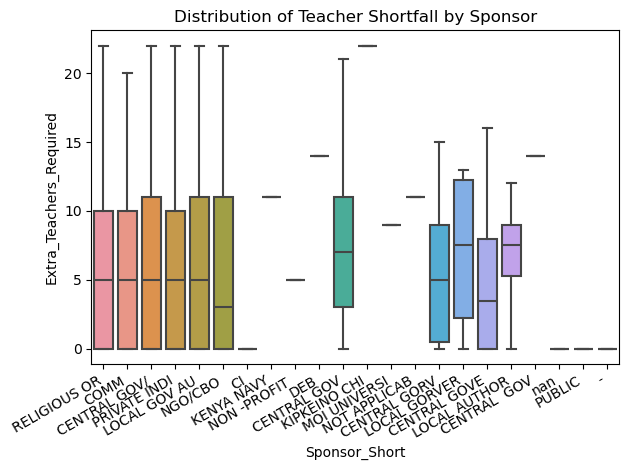

In [13]:
df['Sponsor_Short'] = df['School_Sponsor'].str.replace('ORGANISATION', 'ORG').str.replace('GOVERNMENT', 'GOV').str.replace('COMMUNITY', 'COMM').str.slice(0, 12)

sns.boxplot(
    data=df,
    x='Sponsor_Short',
    y='Extra_Teachers_Required'
)
plt.xticks(rotation=30, ha='right')
plt.title('Distribution of Teacher Shortfall by Sponsor')
plt.tight_layout()
plt.show()


In [17]:
#Total Students and Total Teachers (overall and by region)
total_students_per_district = df.groupby('District')["Total_Students"].sum().sort_values(ascending=False).reset_index()
total_students_per_district.head(10)

,District,Total_Students
0,NAIROBI,676002
1,MACHAKOS,506451
2,MAKUENI,502018
3,NAKURU,500607
4,UASIN GISHU,428844
5,BUNGOMA,388950
6,KITUI,362760
7,THIKA,324767
8,NYERI,305205
9,KAJIADO,296137


In [70]:
#Top 10 schools with highest ratios (where overcrowding is most severe)
#Sort by ratio in descending order

df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'School_ID', 'School_Name', 'School_type',
       'Status', 'School_Sponsor', 'Province', 'District', 'Division',
       'Location', 'Costituency', 'Total_Teachers', 'Total_Students',
       'Students_per_Teacher', 'Actual_Teachers', 'Extra_Teachers_Required',
       'toilets', 'expected_toilets', 'extra_toilets_required', 'classes',
       'expected_classes', 'extra_classes_required', 'Sponsor_Short'],
      dtype='object')